## Section efficace différentielle

Dans ce notebook, on propose de plot la section efficace en fonction de $p_\bot^2$ et de la rapidité y

On rappel la formule de la section efficace: $\sigma_{J/\Psi} = \frac{N_{J/\Psi}^{cor}}{BR(J/\Psi \rightarrow l^+l^-)}\times \frac{\sigma_{MB}}{N_{MB}} $

La variable dépendant de y et $p_\bot^2$ est $N_{J/\Psi}^{cor} = N_{J/\Psi}(y,p_\bot^2)/\left< A \times \varepsilon \right>(y,p_\bot^2)$

In [8]:
import math

import awkward as ak
import hist
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import uproot
import vector

vector.register_awkward()

print("uproot version", uproot.__version__)
print("awkward version", ak.__version__)
print("numpy version", np.__version__)
print("matplotlib version", matplotlib.__version__)
print("hist version", hist.__version__)
print("vector version", vector.__version__)
!ls -alh /pbs/throng/training/nantes-m2-rps-exp/data/*291263*

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2
-rwxrwxr-x 1 2830 training 414M Aug 30  2023 /pbs/throng/training/nantes-m2-rps-exp/data/run291263.data.root
-rwxrwxr-x 1 2830 training  26M Aug 30  2023 /pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root


In [9]:
file = uproot.open("/pbs/throng/training/nantes-m2-rps-exp/data/run291263.data.root")
file.keys()

['eventsTree;1']

In [10]:
events = file["eventsTree"]

m = events.arrays(
    [
        "nMuons",
        "Muon_Px",
        "Muon_Py",
        "Muon_Pz",
        "Muon_Charge",
        "Muon_E",
        "isCMUL",
        "zVtx",
        "Muon_matchedTrgThreshold",
        "isCMSH",
        "isCMLL",
        "Muon_yDCA",
        "Muon_thetaAbs",
    ],
    how="zip",
)
print(len(m))
print(m[10].to_list())
print(m[11].to_list())
print(m[12].to_list())
print(m[13].to_list())

4982352
{'nMuons': 1, 'isCMUL': False, 'zVtx': 6.773909091949463, 'isCMSH': False, 'isCMLL': True, 'Muon': [{'Px': 0.9704122543334961, 'Py': 0.07842636853456497, 'Pz': -12.531188011169434, 'Charge': 1, 'E': 12.569395065307617, 'matchedTrgThreshold': 2, 'yDCA': -1.6824326515197754, 'thetaAbs': 4.620318412780762}]}
{'nMuons': 2, 'isCMUL': True, 'zVtx': -1.0220550298690796, 'isCMSH': False, 'isCMLL': False, 'Muon': [{'Px': 0.5758066177368164, 'Py': 0.7083165645599365, 'Pz': -9.437490463256836, 'Charge': 1, 'E': 9.482123374938965, 'matchedTrgThreshold': 2, 'yDCA': -14.636563301086426, 'thetaAbs': 5.787508964538574}, {'Px': 0.5754270553588867, 'Py': 0.6730052828788757, 'Pz': -9.702540397644043, 'Charge': -1, 'E': 9.743433952331543, 'matchedTrgThreshold': 2, 'yDCA': -12.928074836730957, 'thetaAbs': 5.464372634887695}]}
{'nMuons': 0, 'isCMUL': False, 'zVtx': -1.0220550298690796, 'isCMSH': False, 'isCMLL': False, 'Muon': []}
{'nMuons': 0, 'isCMUL': False, 'zVtx': -1.0220550298690796, 'isCMSH':

Nombre de particules considérées : 285720
Taille de l'histogramme après filtrage : 63517


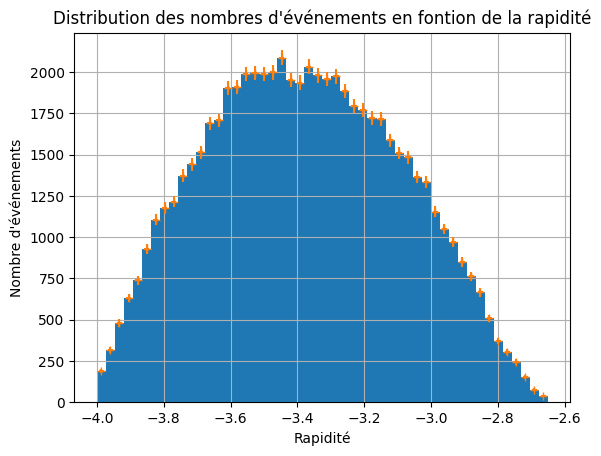

In [31]:
# Filtrer les événements
filtered_events = m[(m.nMuons >= 2) & (abs(m.zVtx) < 10) & (m.isCMUL)]
filtered_events_back = m[(m.nMuons >= 2) & (abs(m.zVtx) < 10)]
print("Nombre de particules considérées :", len(filtered_events))

# Initialiser les vecteurs des muons
muon_vectors = ak.zip(
    {
        "px": filtered_events.Muon.Px,
        "py": filtered_events.Muon.Py,
        "pz": filtered_events.Muon.Pz,
        "E": filtered_events.Muon.E,
        "matchedTrgThreshold": filtered_events.Muon.matchedTrgThreshold,
        "DCA": filtered_events.Muon.yDCA,
        "charge": filtered_events.Muon.Charge,
        "theta": filtered_events.Muon.thetaAbs,
    },
    with_name="Momentum4D",
)


# Combinaisons de paires
muon_pairs = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])

# Paires de charges opposées et filtrage
opposite_charge_pairs = muon_pairs[
    (muon_pairs.muon1.charge != muon_pairs.muon2.charge)
    & (muon_pairs.muon1.matchedTrgThreshold == 2)
    & (muon_pairs.muon2.matchedTrgThreshold == 2)
    & (muon_pairs.muon1.DCA <= 1.5)
    & (muon_pairs.muon2.DCA <= 1.5)
    & (muon_pairs.muon1.theta <= 10)
    & (muon_pairs.muon2.theta <= 10)
    & (muon_pairs.muon1.theta >= 3)
    & (muon_pairs.muon2.theta >= 3)
    & (muon_pairs.muon1.eta <= -2.5)
    & (muon_pairs.muon1.eta <= -2.5)
    & (muon_pairs.muon2.eta >= -4)
    & (muon_pairs.muon2.eta >= -4)
]

# Calcul des masses invariantes et de la rapidité
masses_opposite = (opposite_charge_pairs.muon1 + opposite_charge_pairs.muon2).mass
y_pair = (opposite_charge_pairs.muon1 + opposite_charge_pairs.muon2).rapidity

filtered_y_pair = ak.flatten(y_pair[(y_pair <= -2.5) & (y_pair >= -4)])

# Calcul des histogrammes avec numpy
bins = 50
hist_y, bin_edges = np.histogram(filtered_y_pair, bins=bins)
print("Taille de l'histogramme après filtrage :", len(flattened_opposite))

# Tracer l'histogramme
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_err = (bin_edges[2]-bin_edges[1])/(2*np.sqrt(3))
plt.hist(filtered_y_pair, bins=bins)
plt.errorbar(bin_centers, hist_y ,xerr=bin_err , yerr= np.sqrt(hist_y),fmt='+')
plt.xlabel("Rapidité")
plt.ylabel("Nombre d'événements")
plt.title("Distribution des nombres d'événements en fontion de la rapidité")
plt.grid(True)
plt.show()

> Reconstrucion de $\sigma$ en fonction de y

In [ ]:
#Introduction des variables
BR = 5.94/100
D_BR = 0.06/100
sig_MB = 57.52
D_sig_MB = np.sqrt(0.03**2 + 1.14**2) 
N_MB = 2593403501
D_N_MB = 4000000
#Introduction des variables
N_JPsi = hist_y
AccEff = [] #doivent être de la même taille

